In [1]:
import pandas as pd
import plotly.graph_objects as go

df=pd.read_csv("../data/shopsmart_experiment.csv")
df.head()

,user_id,signup_date,cohort_month,variant,visited_site,added_to_cart,started_checkout,completed_purchase,revenue,month_1_active,month_2_active,month_3_active
0,U100000,2026-04-21,2026-04,treatment,1,1,0,0,0.0,0,0,0
1,U100001,2026-06-25,2026-06,control,1,0,0,0,0.0,0,0,0
2,U100002,2026-06-04,2026-06,control,1,0,0,0,0.0,0,0,0
3,U100003,2026-05-20,2026-05,treatment,1,1,1,0,0.0,0,0,0
4,U100004,2026-03-13,2026-03,treatment,1,1,0,0,0.0,0,0,0


In [2]:
retention=df.groupby("variant")[["month_1_active","month_2_active","month_3_active"]].mean()*100
retention.columns=["Month 1", "Month 2", "Month 3"]
retention                   
                                 

,Month 1,Month 2,Month 3
variant,,,
control,33.191489,15.506383,8.391489
treatment,37.632653,20.375510,11.869388


In [5]:
%pip install --upgrade plotly


   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 373.0 kB/s eta 0:00:26
   -- ------------------------------------- 0.5/9.9 MB 373.0 kB/s eta 0:00:26
   -- ------------------------------------- 0.5/9.9 MB 373.0 kB/s eta 0:00:26
   -- ------------------------------------- 0.5/9.9 MB 373.0 kB/s eta 0:00:26
   -- ------------------------------------- 0.5/9.9 MB 373.0 kB/s eta 0:00:26
   -- ------------------------------------- 0.5/9.9 MB 37

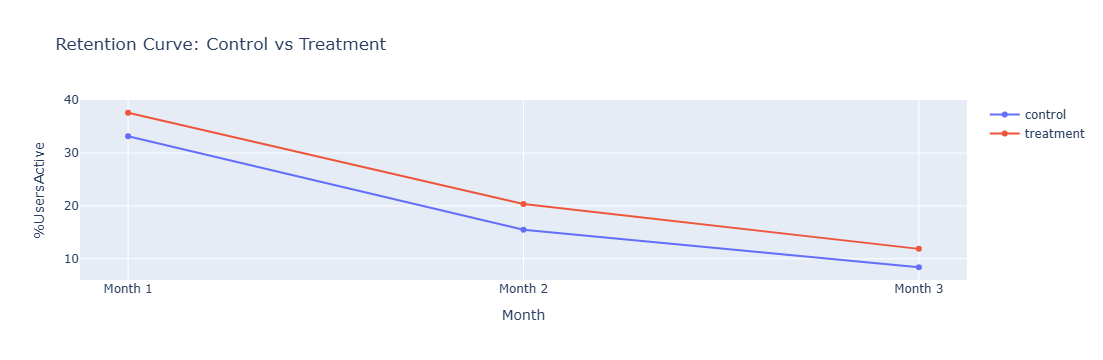

In [3]:
fig=go.Figure()
for variant in retention.index:
    fig.add_trace(go.Scatter(x=["Month 1", "Month 2", "Month 3"],
                            y=retention.loc[variant],
                            mode="lines+markers",
                            name=variant))
fig.update_layout(title="Retention Curve: Control vs Treatment",
                  yaxis_title="%UsersActive",xaxis_title="Month")
fig.show()

In [8]:
%pip install kaleido


   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------- ----------------------- 2/5 [logistro]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   -------------------------------- ------- 4/5 [kaleido]
   -------------------------------- ------- 4/5 [kaleido]
   ----------

In [4]:
fig.write_image("../screenshots/retentiom_curve.png")